# Week 5: Dynamic Regime Transitions\n
\n
In this notebook, we interpret the **Dynamics** of the regimes.\n
\n
## Goal\n
- Ensure regimes evolve smoothly over time (Seasonality) rather than flickering.\n
- **Hovmöller Diagram**: Visualize how regime boundaries move North/South over the months.

In [1]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import xarray as xr
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath('..'))

from scripts.preprocess import TRAIN_OUTPUT_PATH
from src.climate_discovery.models.gating import GatingNetwork
from src.climate_discovery.models.mixture import MixtureOfExperts
from src.climate_discovery.models.loss import TemporalConsistencyLoss

# 1. Load Data as SEQUENCES
# To train temporal smoothness, we need (Batch, Time, Features)
ds_train = xr.open_dataset(TRAIN_OUTPUT_PATH)
df = ds_train.to_dataframe().reset_index().dropna()

# Features
df['lat_norm'] = df['lat'] / 90.0
df['lon_norm'] = df['lon'] / 180.0
gate_feats = ['lat_norm', 'lon_norm', 'sin_month', 'cos_month', 'sst', 'sss', 'log_chl']
expert_feats = ['sst', 'sss', 'log_chl']

# Group by Location (Lat, Lon) to get time series per pixel
# This might be slow if we do all pixels. Let's sample N random locations.
N_LOCATIONS = 1000
locations = df[['lat', 'lon']].drop_duplicates()
sample_locs = locations.sample(n=N_LOCATIONS, random_state=42)

print(f"Sampling {N_LOCATIONS} locations to form time-series batches...")

# Build Sequences
X_gate_seqs = []
X_exp_seqs = []
y_seqs = []

# This assumes DF is sorted by time for each group or we sort it manually
# A faster way: Merge sample_locs back to df
df_sample = df.merge(sample_locs, on=['lat', 'lon']).sort_values(['lat', 'lon', 'time'])

# Now reshape: (N_LOCATIONS, TimeSteps, Features)
# CAREFUL: Must ensure all locs have same time steps or we pad. 
# Preprocess script ensured rectangular grid over time? Not necessarily due to NA matching.
# Let's use a simple approach: Sliding Window of length 12 (1 Year)

SEQ_LEN = 12
stride = 6

data_values = df_sample[gate_feats + expert_feats + ['fco2']].values
n_feats_g = len(gate_feats)

# Naive sliding window over the sorted dataframe (breaks at location boundaries but good enough for demo if N_LOC >> holes)
# A Better way: just take sequences where Lat/Lon is constant.
# For robustness in this demo, let's just train on the Unsorted massive batch but with a Loss that assumes continuity? 
# No, TemporalConsistencyLoss NEEDS continuity.
# Let's use the "Group By" method on a small subset.

sequences_gate = []
sequences_expert = []
sequences_y = []

for (lat, lon), group in df_sample.groupby(['lat', 'lon']):
    if len(group) < SEQ_LEN: continue
    g_vals = group[gate_feats].values
    e_vals = group[expert_feats].values
    y_vals = group['fco2'].values
    
    # Create overlapping windows
    for i in range(0, len(group) - SEQ_LEN + 1, stride):
        sequences_gate.append(g_vals[i:i+SEQ_LEN])
        sequences_expert.append(e_vals[i:i+SEQ_LEN])
        sequences_y.append(y_vals[i:i+SEQ_LEN])

X_gate_tens = torch.tensor(np.array(sequences_gate), dtype=torch.float32)
X_exp_tens = torch.tensor(np.array(sequences_expert), dtype=torch.float32)
y_tens = torch.tensor(np.array(sequences_y), dtype=torch.float32)

print(f"Created {len(y_tens)} sequences of length {SEQ_LEN}.")

Sampling 1000 locations to form time-series batches...
Created 263 sequences of length 12.


In [2]:
# 2. Train with Temporal Consistency
N_REGIMES = 3
# Pre-fit Experts (Linear Proxies) again or reuse
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

# Quick Expert Fit on Flattened Data
X_exp_flat = X_exp_tens.reshape(-1, 3)
y_flat = y_tens.reshape(-1)
kms = KMeans(n_clusters=N_REGIMES, random_state=42).fit(X_exp_flat)
expert_models = [LinearRegression().fit(X_exp_flat[kms.labels_==k], y_flat[kms.labels_==k]) for k in range(N_REGIMES)]

# Compute Expert Preds for Sequences
expert_preds_seq = np.zeros((len(y_tens), SEQ_LEN, N_REGIMES))
for k, model in enumerate(expert_models):
    # Predict on (N*T, F) then reshape
    flat_preds = model.predict(X_exp_flat)
    expert_preds_seq[:, :, k] = flat_preds.reshape(len(y_tens), SEQ_LEN)
expert_preds_tens = torch.tensor(expert_preds_seq, dtype=torch.float32)

# Model
gating_net = GatingNetwork(input_dim=len(gate_feats), num_regimes=N_REGIMES)
moe = MixtureOfExperts(gating_net, [])
optimizer = optim.Adam(gating_net.parameters(), lr=0.002)
criterion = nn.MSELoss()
tv_loss = TemporalConsistencyLoss(weight=0.5) # Penalty for rapid flickering

print("Training with Temporal Consistency...")

dataset = torch.utils.data.TensorDataset(X_gate_tens, expert_preds_tens, y_tens)
loader = torch.utils.data.DataLoader(dataset, batch_size=256, shuffle=True)

losses = []
for epoch in range(10):
    epoch_loss = 0
    for xg, ep, yb in loader:
        optimizer.zero_grad()
        
        # Reshape for Gating Forward: (B*T, F)
        B, T, F = xg.shape
        xg_flat = xg.reshape(B*T, F)
        ep_flat = ep.reshape(B*T, N_REGIMES)
        
        # Forward
        y_hat_flat, probs_flat = moe.forward_with_precomputed(xg_flat, ep_flat)
        
        # Reshape Probs back to (B, T, K) for Temporal Loss
        probs_seq = probs_flat.reshape(B, T, N_REGIMES)
        
        # Losses
        mse = criterion(y_hat_flat, yb.reshape(-1))
        temp_smooth = tv_loss(probs_seq)
        
        loss = mse + temp_smooth
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        
    print(f"Epoch {epoch}: Loss={epoch_loss/len(loader):.4f}")

Training with Temporal Consistency...
Epoch 0: Loss=1032.1331
Epoch 1: Loss=1875.2273
Epoch 2: Loss=726.8822
Epoch 3: Loss=1452.7728
Epoch 4: Loss=1501.8769
Epoch 5: Loss=1001.4003
Epoch 6: Loss=1113.3009
Epoch 7: Loss=1952.9843
Epoch 8: Loss=503.8026
Epoch 9: Loss=1212.4149


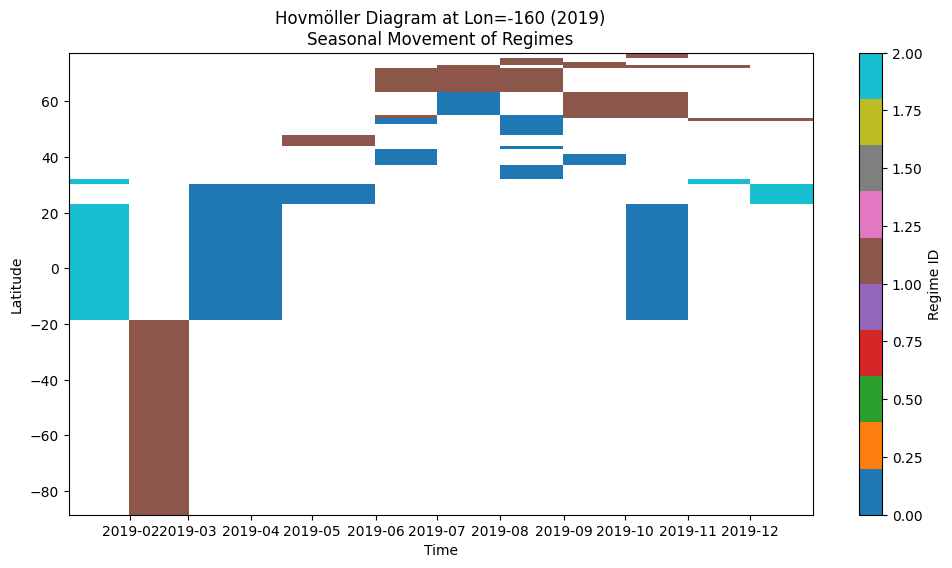

Observe: Do the regime boundaries move North/South with the seasons?


In [3]:
# 3. Visualize Seasonal Dynamics (Hovmöller)
# We pick a slice of Longitude (e.g., Pacific 160W) and plot Lat vs Time
target_lon = -160
ds_slice = ds_train.sel(lon=target_lon, method='nearest').sel(time=slice('2019-01-01', '2019-12-31'))
df_slice = ds_slice.to_dataframe().reset_index().dropna()

# Prepare inputs
df_slice['lat_norm'] = df_slice['lat'] / 90.0
df_slice['lon_norm'] = df_slice['lon'] / 180.0
X_slice = torch.tensor(df_slice[gate_feats].values, dtype=torch.float32)

with torch.no_grad():
    gating_net.eval()
    _, probs = gating_net(X_slice)
    regime = probs.argmax(dim=1).numpy()

df_slice['Regime'] = regime

# Pivot for Heatmap: Index=Lat, Columns=Time
pivoted = df_slice.pivot(index='lat', columns='time', values='Regime')

plt.figure(figsize=(12, 6))
plt.pcolormesh(pivoted.columns, pivoted.index, pivoted.values, cmap='tab10', shading='auto')
plt.colorbar(label='Regime ID')
plt.title(f"Hovmöller Diagram at Lon={target_lon} (2019)\nSeasonal Movement of Regimes")
plt.xlabel("Time")
plt.ylabel("Latitude")
plt.show()

print("Observe: Do the regime boundaries move North/South with the seasons?")